In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (log_loss)
import joblib
from tfm_segunda.evaluate_models import evaluar_modelo, graficar_matriz_confusion
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import warnings

from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz


warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')
PROJECT_ROOT = Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True, parents=True)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

In [2]:
dataset_path = DATA_PROCESSED / "dataset_modelado.parquet"
df = pd.read_parquet(dataset_path)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nFilas por split:")
print(df['split'].value_counts())
train = df[df['split'] == 'train'].copy()
validation = df[df['split'] == 'validation'].copy()
test = df[df['split'] == 'test'].copy()

print(f"Train:      {len(train):>5,} filas  |  fechas {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Validation: {len(validation):>5,} filas  |  fechas {validation['date'].min().date()} → {validation['date'].max().date()}")
print(f"Test:       {len(test):>5,} filas  |  fechas {test['date'].min().date()} → {test['date'].max().date()}")
META_COLS = ['split', 'season', 'date', 'jornada', 'home_team', 'away_team', 'fthg', 'ftag']
TARGET_COLS = ['ftr']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + TARGET_COLS]

Dataset cargado: 7,295 filas × 41 columnas

Filas por split:
split
train         4592
validation    1373
test           923
demo           407
Name: count, dtype: int64
Train:      4,592 filas  |  fechas 2010-08-27 → 2020-08-07
Validation: 1,373 filas  |  fechas 2020-09-12 → 2023-05-28
Test:         923 filas  |  fechas 2023-08-11 → 2025-06-01


In [3]:
def preparar_xy(particion, feature_cols):
    mask_completas = particion[feature_cols].notna().all(axis=1)
    p = particion.loc[mask_completas].copy()
    
    X = p[feature_cols].astype(float)
    y = p['ftr']
    return X, y


X_train, y_train = preparar_xy(train, FEATURE_COLS)
X_val, y_val = preparar_xy(validation, FEATURE_COLS)
X_test, y_test = preparar_xy(test, FEATURE_COLS)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


X_train: (4482, 32), y_train: (4482,)
X_val: (1338, 32), y_val: (1338,)
X_test: (901, 32), y_test: (901,)


In [4]:
from scipy.stats import randint

param_dist = {
    'n_estimators':      randint(200, 1200),
    'max_depth':         [None, 4, 6, 8, 10, 14, 20],
    'min_samples_split': randint(2, 40),
    'min_samples_leaf':  randint(1, 30),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'bootstrap':         [True],
    'criterion':         ['gini', 'log_loss'],
}

param_dist_balanced = {**param_dist, 'class_weight': ['balanced', 'balanced_subsample']}
param_dist_simple   = {**param_dist, 'class_weight': [None]}

In [5]:
rs = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions = param_dist_simple,
    n_iter              = 60,
    cv                  = TimeSeriesSplit(n_splits=5),
    scoring             = 'neg_log_loss',
    n_jobs              = -1,
    verbose             = 1,
    refit               = True,
    random_state        = SEED,
)
rs.fit(X_train, y_train)
print("Mejores params (simple):", rs.best_params_)
print(f"Mejor log-loss CV: {-rs.best_score_:.4f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Mejores params (simple): {'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 28, 'min_samples_split': 8, 'n_estimators': 400}
Mejor log-loss CV: 1.0495


In [6]:
rs_balanced = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions = param_dist_balanced,
    n_iter              = 60,
    cv                  = TimeSeriesSplit(n_splits=5),
    scoring             = 'neg_log_loss',
    n_jobs              = -1,
    verbose             = 1,
    refit               = True,
    random_state        = SEED,
)
rs_balanced.fit(X_train, y_train)
print("Mejores params (balanced):", rs_balanced.best_params_)
print(f"Mejor log-loss CV: {-rs_balanced.best_score_:.4f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Mejores params (balanced): {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 655}
Mejor log-loss CV: 1.0711


In [7]:
bp = rs.best_params_
fine_grid = {
    'n_estimators':      [max(100, bp['n_estimators']-200), bp['n_estimators'], bp['n_estimators']+200],
    'max_depth':         [bp['max_depth']],
    'min_samples_leaf':  sorted(set([max(1, bp['min_samples_leaf']-2), bp['min_samples_leaf'], bp['min_samples_leaf']+2])),
    'min_samples_split': sorted(set([max(2, bp['min_samples_split']-4), bp['min_samples_split'], bp['min_samples_split']+4])),
    'max_features':      [bp['max_features']],
    'criterion':         [bp['criterion']],
}

gs_fine = GridSearchCV(
    estimator   = RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid  = fine_grid,
    cv          = TimeSeriesSplit(n_splits=5),
    scoring     = 'neg_log_loss',
    n_jobs      = -1,
    verbose     = 1,
    refit       = True,
)
gs_fine.fit(X_train, y_train)
print("Mejores params (refinado):", gs_fine.best_params_)
print(f"Mejor log-loss CV refinado: {-gs_fine.best_score_:.4f}")


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores params (refinado): {'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 30, 'min_samples_split': 4, 'n_estimators': 400}
Mejor log-loss CV refinado: 1.0494


In [17]:
bp_b = rs_balanced.best_params_
fine_grid_b = {
    'n_estimators':      [400, 600, 800],
    'max_depth':         [3, 4, 5],
    'min_samples_leaf':  [30, 50, 80],
    'min_samples_split': [10, 20],
    'max_features':      ['sqrt', 0.3],
    'criterion':         ['log_loss'],
    'class_weight':      ['balanced', 'balanced_subsample'],
}
gs_fine_b = GridSearchCV(RandomForestClassifier(random_state=SEED, n_jobs=-1),
                        fine_grid_b, cv=TimeSeriesSplit(5),
                        scoring='neg_log_loss', n_jobs=-1, refit=True, verbose=1)
gs_fine_b.fit(X_train, y_train)
rf_balanced = gs_fine_b.best_estimator_
print("Mejores params (balanced refinado):", gs_fine_b.best_params_)
print(f"Mejor log-loss CV: {-gs_fine_b.best_score_:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores params (balanced refinado): {'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 5, 'max_features': 0.3, 'min_samples_leaf': 50, 'min_samples_split': 10, 'n_estimators': 800}
Mejor log-loss CV: 1.0780


In [18]:
rf_simple   = gs_fine.best_estimator_
rf_balanced = gs_fine_b.best_estimator_


In [19]:
LABELS = ['A', 'D', 'H']
LOG_LOSS_MERCADO = 1.037

def evaluar_split(modelo, nombre_modelo, nombre_split, X, y):
    y_pred  = modelo.predict(X)
    y_proba = pd.DataFrame(
        modelo.predict_proba(X),
        columns=modelo.classes_,
    )[LABELS].values
    res = evaluar_modelo(y, y_pred, y_proba,
                         f'{nombre_modelo} · {nombre_split}',
                         verbose=False)
    res['variante'] = nombre_modelo
    res['split']    = nombre_split
    return res

filas = []
for nombre_modelo, modelo in [('RF Balanced', rf_balanced),
                              ('RF Sin pesos', rf_simple)]:
    for nombre_split, X, y in [('train', X_train, y_train),
                                ('validation', X_val, y_val),
                                ('test', X_test, y_test)]:
        filas.append(evaluar_split(modelo, nombre_modelo, nombre_split, X, y))

tabla = (pd.DataFrame(filas)
         [['variante', 'split', 'accuracy', 'f1_macro',
           'f1_A', 'f1_D', 'f1_H', 'log_loss']]
         .assign(delta_vs_mercado=lambda d: d['log_loss'] - LOG_LOSS_MERCADO))

print(tabla.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


    variante      split  accuracy  f1_macro   f1_A   f1_D   f1_H  log_loss  delta_vs_mercado
 RF Balanced      train    0.4795    0.4701 0.4600 0.4124 0.5379    1.0418            0.0048
 RF Balanced validation    0.4350    0.4229 0.4415 0.3109 0.5164    1.0689            0.0319
 RF Balanced       test    0.4206    0.3963 0.3993 0.2628 0.5269    1.0717            0.0347
RF Sin pesos      train    0.4828    0.2935 0.1921 0.0484 0.6398    1.0210           -0.0160
RF Sin pesos validation    0.4492    0.2805 0.2075 0.0236 0.6103    1.0409            0.0039
RF Sin pesos       test    0.4639    0.2673 0.1612 0.0148 0.6259    1.0350           -0.0020


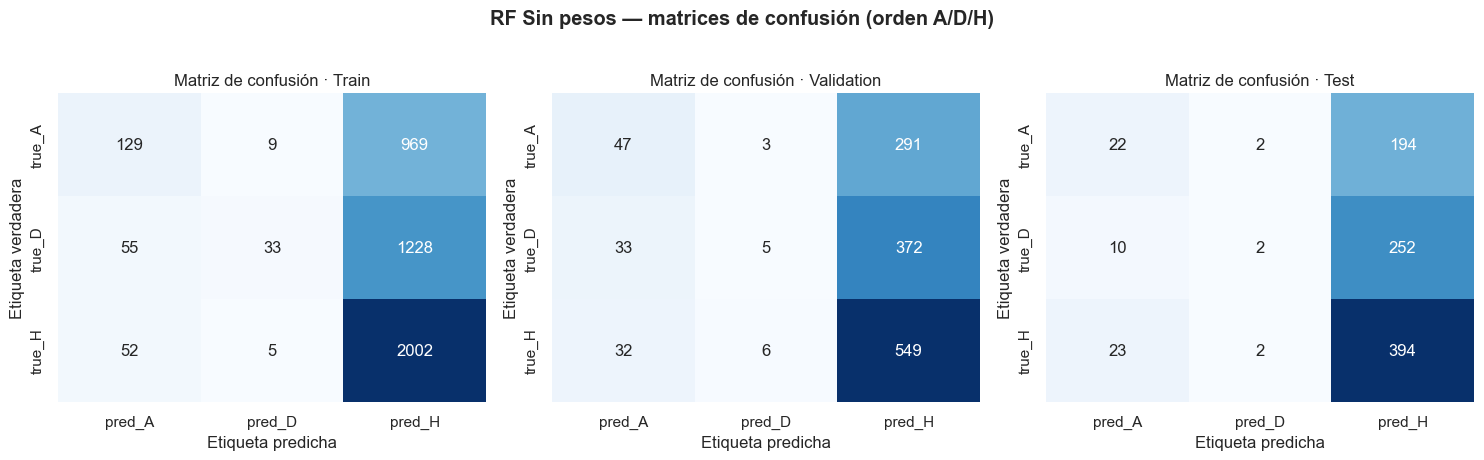

In [20]:
resultados_simple = {
    'Train':      evaluar_split(rf_simple, 'RF', 'Train',      X_train, y_train),
    'Validation': evaluar_split(rf_simple, 'RF', 'Validation', X_val,   y_val),
    'Test':       evaluar_split(rf_simple, 'RF', 'Test',       X_test,  y_test),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nombre, res) in zip(axes, resultados_simple.items()):
    cm = np.array(res['confusion_matrix'])
    graficar_matriz_confusion(cm, LABELS, nombre, ax=ax)
plt.suptitle('RF Sin pesos — matrices de confusión (orden A/D/H)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


Top features (RF sin pesos):
prob_h               0.236205
match_uncertainty    0.128101
away_elo_pre         0.057874
away_gd_pre          0.055345
home_mv              0.048922
home_elo_pre         0.045178
home_gd_pre          0.041480
away_mv              0.041068
away_pos_pre         0.033637
away_ppg_10          0.028609
home_ppg_10          0.026127
away_gc_10           0.025809
away_pts_pre         0.019688
home_pts_pre         0.018897
home_ppg_5           0.016223
away_gc_3            0.015810
home_pos_pre         0.015588
away_gc_5            0.013462
home_gf_10           0.013365
home_rest_days       0.012737
home_gf_5            0.011444
home_gc_10           0.011372
away_ppg_5           0.010246
away_ppg_3           0.009983
home_gf_3            0.009069
away_rest_days       0.008722
away_gf_10           0.008258
away_gf_5            0.007920
home_ppg_3           0.007662
home_gc_5            0.007380
home_gc_3            0.007170
away_gf_3            0.006650
dtype: floa

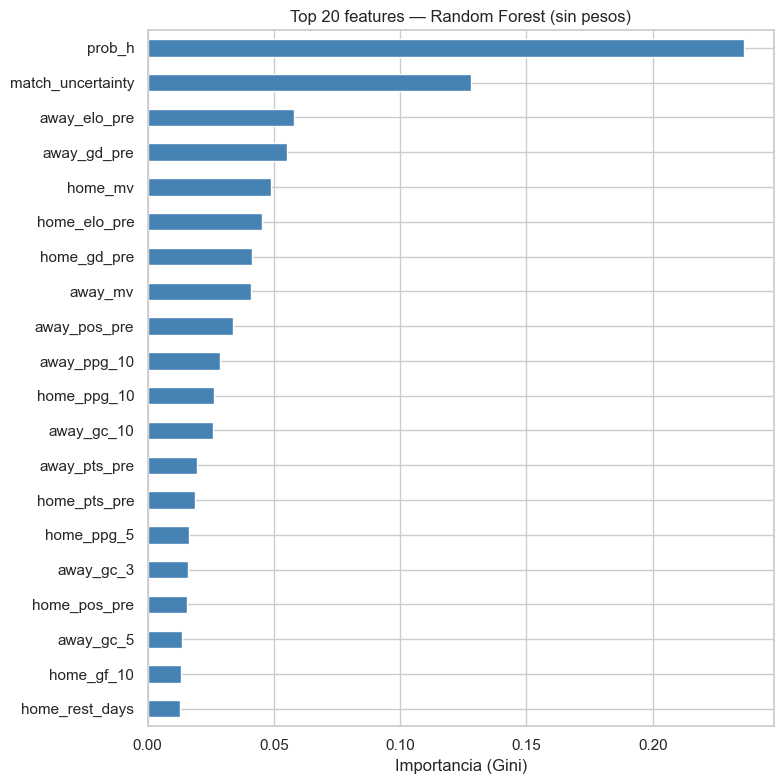

In [21]:
importancias = pd.Series(
    rf_simple.feature_importances_,
    index=FEATURE_COLS,
).sort_values(ascending=False)

print("Top features (RF sin pesos):")
print(importancias)

fig, ax = plt.subplots(figsize=(8, 8))
importancias.head(20).iloc[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 20 features — Random Forest (sin pesos)')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()


In [22]:
joblib.dump(rf_balanced, MODELS_DIR / 'random_forest_balanced.pkl')
joblib.dump(rf_simple, MODELS_DIR / 'random_forest_simple.pkl')


['/Users/pedrosarm/Desktop/TFM/Code/notebooks/models/random_forest_simple.pkl']